# Clustering analysis

Start by inspecting the saved daily dataset. Feature preparation and clustering will be added to this notebook in the next steps.

Run from the repository folder with the `.venv` kernel. This notebook uses local data only; run `01_daily_macro_dataset.ipynb` first if the CSV is missing.

In [8]:
import numpy as np
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


## Load and preview

Load the version that preserves all equity trading dates and missing macro observations. No filling or scaling is applied.

In [9]:
df = pd.read_csv("data/daily_macro_levels.csv", index_col="date", parse_dates=["date"])
df.head()

,sp500,breakeven_10y,real_yield_10y,slope_10y_2y,vix,vix3m,vix_term_spread
date,,,,,,,
2011-10-05,1144.030029,1.80,0.12,1.67,37.81,38.31,-0.50
2011-10-06,1164.969971,1.88,0.13,1.72,36.27,37.04,-0.77
2011-10-07,1155.459961,1.94,0.16,1.80,36.20,37.31,-1.11
2011-10-10,1194.890015,NaN,NaN,NaN,33.02,34.79,-1.77
2011-10-11,1195.540039,1.95,0.23,1.86,32.86,34.06,-1.20


In [10]:
df.isnull().sum()

sp500               0
breakeven_10y      28
real_yield_10y     29
slope_10y_2y       28
vix                 0
vix3m               0
vix_term_spread     0
dtype: int64

In [11]:
df_complete = df.dropna()
df_complete.isnull().sum()

sp500              0
breakeven_10y      0
real_yield_10y     0
slope_10y_2y       0
vix                0
vix3m              0
vix_term_spread    0
dtype: int64

## Daily levels: compact mosaic

One time-series panel per variable, with a shared date axis and separate vertical scales. Use the complete observations in `df_complete`. The term spread is **VIX − VIX3M**.

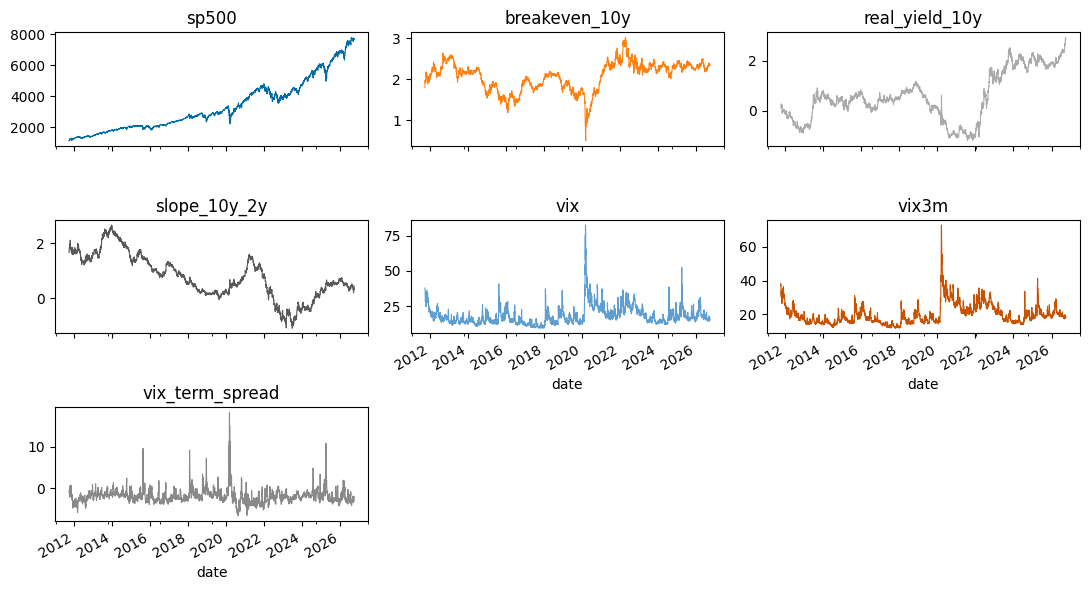

In [12]:
with plt.style.context("tableau-colorblind10"):
    axes = df_complete.plot(subplots=True, layout=(3, 3), figsize=(11, 6),
                   sharex=True, legend=False, linewidth=0.8)
    for ax, column in zip(axes.flat, df_complete.columns):
        ax.set_title(column)
    plt.tight_layout()
    plt.show()

## S&P 500 log returns

Chapter 3.2.1 uses previously calculated equity log returns. Here we calculate them from our S&P 500 levels; the other variables remain in levels. Calculate returns on `df` before dropping missing rows to preserve the equity trading-day intervals.

In [13]:
df_transformed = df.copy()
df_transformed["sp500"] = np.log(df["sp500"]).diff()
df_transformed = df_transformed.rename(columns={"sp500": "sp500_log_return"}).dropna()
df_transformed.head()

,sp500_log_return,breakeven_10y,real_yield_10y,slope_10y_2y,vix,vix3m,vix_term_spread
date,,,,,,,
2011-10-06,0.018138,1.88,0.13,1.72,36.27,37.04,-0.77
2011-10-07,-0.008197,1.94,0.16,1.80,36.20,37.31,-1.11
2011-10-11,0.000544,1.95,0.23,1.86,32.86,34.06,-1.20
2011-10-12,0.009747,1.98,0.26,1.95,31.26,32.97,-1.71
2011-10-13,-0.002978,1.92,0.27,1.90,30.70,32.71,-2.01


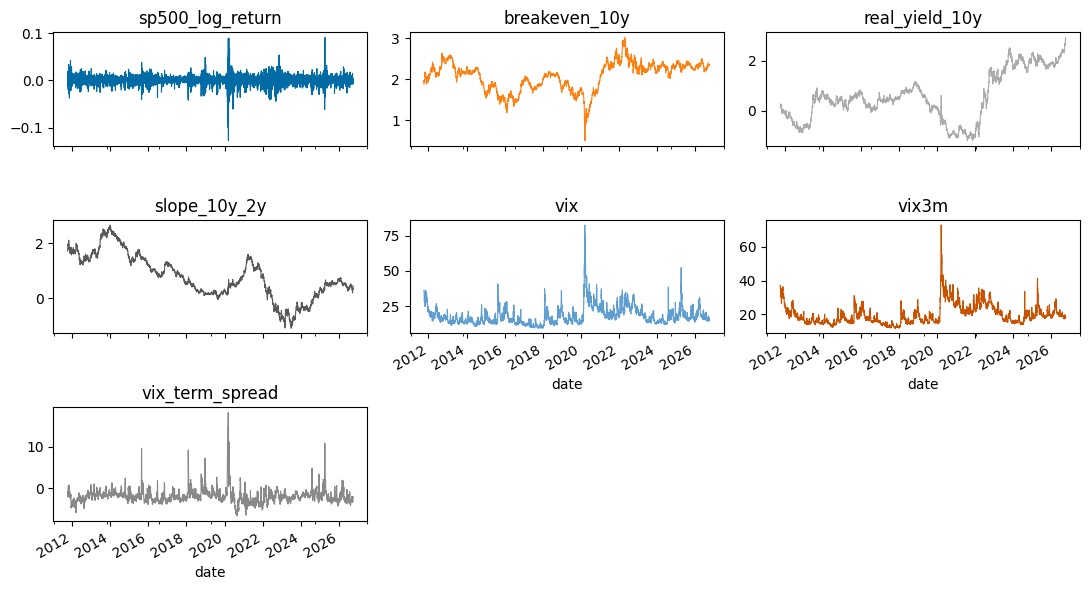

In [14]:
with plt.style.context("tableau-colorblind10"):
    axes = df_transformed.plot(subplots=True, layout=(3, 3), figsize=(11, 6),
                               sharex=True, legend=False, linewidth=0.8)
    for ax, column in zip(axes.flat, df_transformed.columns):
        ax.set_title(column)
    plt.tight_layout()
    plt.show()

## Clustering

To be developed next: choose features and transformations, then fit and evaluate clusters.

In [15]:
df_transformed = df.copy()
df_transformed["sp500"] = np.log(df["sp500"]).diff()
df_transformed = df_transformed.rename(columns={"sp500": "sp500_log_return"}).dropna()
df_transformed.head()

,sp500_log_return,breakeven_10y,real_yield_10y,slope_10y_2y,vix,vix3m,vix_term_spread
date,,,,,,,
2011-10-06,0.018138,1.88,0.13,1.72,36.27,37.04,-0.77
2011-10-07,-0.008197,1.94,0.16,1.80,36.20,37.31,-1.11
2011-10-11,0.000544,1.95,0.23,1.86,32.86,34.06,-1.20
2011-10-12,0.009747,1.98,0.26,1.95,31.26,32.97,-1.71
2011-10-13,-0.002978,1.92,0.27,1.90,30.70,32.71,-2.01


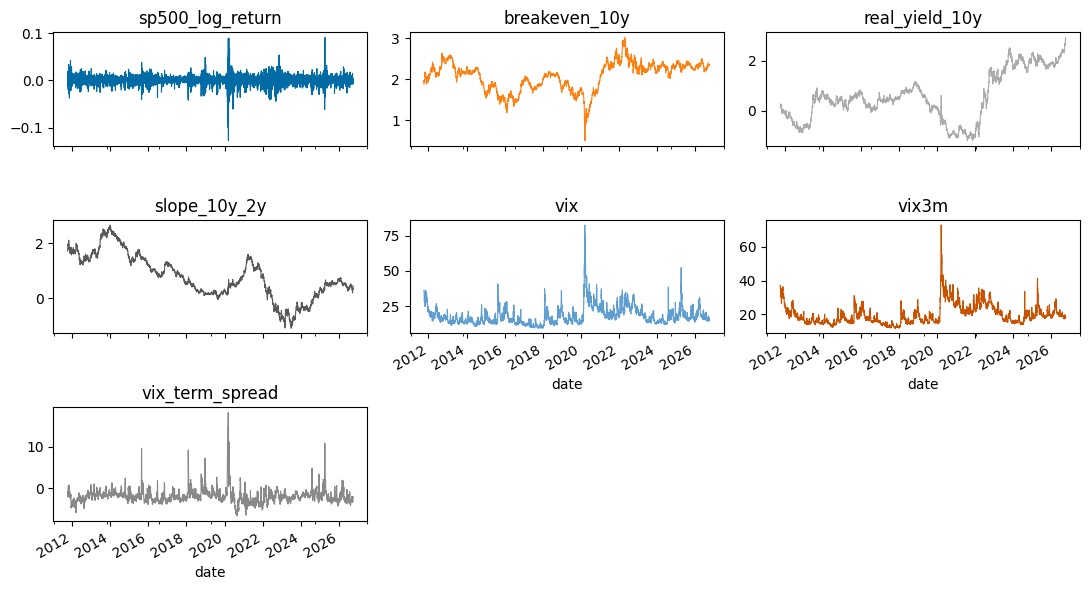

In [16]:
with plt.style.context("tableau-colorblind10"):
    axes = df_transformed.plot(subplots=True, layout=(3, 3), figsize=(11, 6),
                               sharex=True, legend=False, linewidth=0.8)
    for ax, column in zip(axes.flat, df_transformed.columns):
        ax.set_title(column)
    plt.tight_layout()
    plt.show()

## Conventional partitioning

This plot shows a potential partitioning of the market variables with a 25-75 percentile low-mid-high logic. 

This can offer intuitive interpretability certain cases. A major risk is that the joint occurrance of certian states get too low, sparse. In this current configuration there are 3 exp 7 joint states. It is almost impossible to understand all those scenarios. Instead, I propose unsupervised technique to compress the states down to smaller number with distinguishable profiles. 

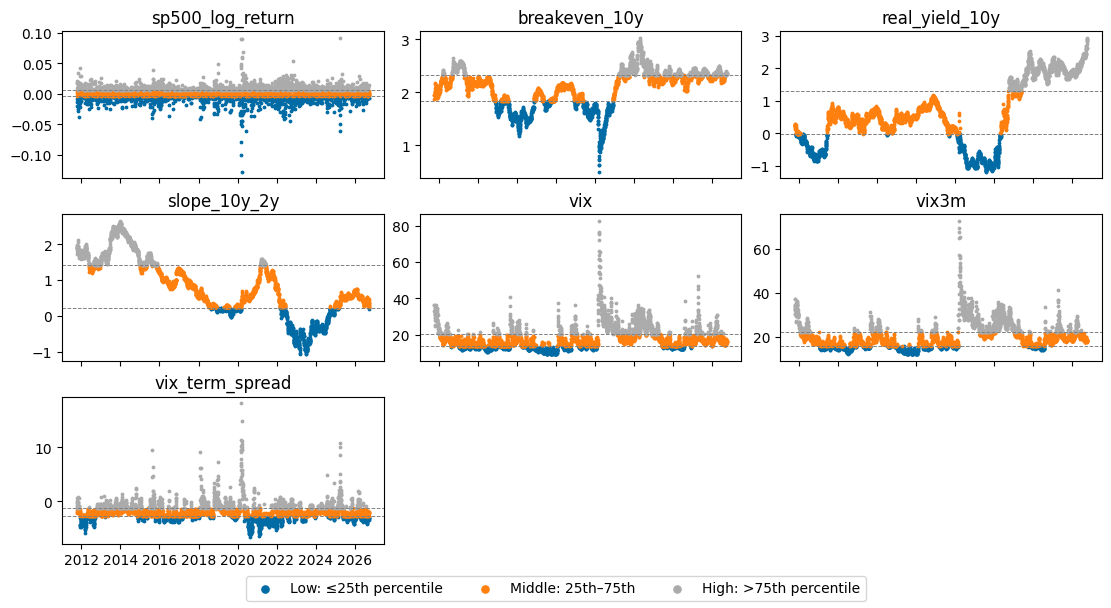

In [17]:
with plt.style.context("tableau-colorblind10"):
    fig, axes = plt.subplots(3, 3, figsize=(11, 6), sharex=True, layout="constrained")
    for ax, column in zip(axes.flat, df_transformed.columns):
        series = df_transformed[column]
        q25, q75 = series.quantile([0.25, 0.75])
        partitions = {
            "Low: ≤25th percentile": series <= q25,
            "Middle: 25th–75th": (series > q25) & (series <= q75),
            "High: >75th percentile": series > q75,
        }
        for label, mask in partitions.items():
            ax.scatter(series.index[mask], series[mask], s=3, label=label)
        for threshold in [q25, q75]:
            ax.axhline(threshold, color="grey", linestyle="--", linewidth=0.7)
        ax.set_title(column)

    for ax in axes.flat[len(df_transformed.columns):]:
        ax.set_visible(False)
    fig.legend(*axes.flat[0].get_legend_handles_labels(),
               loc="outside lower center", ncol=3, markerscale=3)
    plt.show()

## EDA

In [18]:
df_transformed.describe(include = 'all').T

,count,mean,std,min,25%,50%,75%,max
sp500_log_return,3740.0,0.000491,0.010607,-0.127652,-0.003765,0.000661,0.005631,0.090895
breakeven_10y,3740.0,2.073099,0.348325,0.500000,1.830000,2.160000,2.320000,3.020000
real_yield_10y,3740.0,0.570620,0.959831,-1.190000,-0.030000,0.480000,1.312500,2.930000
slope_10y_2y,3740.0,0.781896,0.808400,-1.080000,0.230000,0.670000,1.410000,2.660000
vix,3740.0,17.909366,6.587687,9.140000,13.587500,16.270000,20.332500,82.690000
vix3m,3740.0,19.868682,5.891972,11.850000,15.700000,18.480000,22.010000,72.980000
vix_term_spread,3740.0,-1.959316,1.658523,-6.660000,-2.840000,-2.110000,-1.310000,18.230000


In [20]:
from sklearn.preprocessing import StandardScaler
# Scaling the data before clustering
scaler = StandardScaler()
subset = df_transformed.copy()
subset_scaled = scaler.fit_transform(subset)

In [21]:
subset_scaled_df = pd.DataFrame(
    subset_scaled, columns=subset.columns, index=subset.index
)

In [48]:
subset_scaled_df.head()

,sp500_log_return,breakeven_10y,real_yield_10y,slope_10y_2y,vix,vix3m,vix_term_spread
date,,,,,,,
2011-10-06,1.663919,-0.554439,-0.459122,1.160601,2.787487,2.914748,0.717189
2011-10-07,-0.819160,-0.382163,-0.427862,1.259576,2.776859,2.960579,0.512160
2011-10-11,0.004982,-0.353450,-0.354923,1.333806,2.269785,2.408907,0.457888
2011-10-12,0.872735,-0.267312,-0.323663,1.445152,2.026875,2.223885,0.150344
2011-10-13,-0.327097,-0.439588,-0.313243,1.383293,1.941857,2.179751,-0.030564


In [23]:
# Importing PCA
from sklearn.decomposition import PCA

# Defining the number of principal components to generate
n = subset.shape[1]                                                 # Storing the number of variables in the data

pca = PCA(n_components = n, random_state = 1)                       # Storing PCA function with n components

data_pca = pd.DataFrame(pca.fit_transform(subset_scaled_df ))       # Applying PCA on scaled data

# The percentage of variance explained by each principal component is stored
exp_var = (pca.explained_variance_ratio_)
exp_var

array([3.42541917e-01, 2.26639742e-01, 1.47364149e-01, 1.33315139e-01,
       1.03273936e-01, 4.68651180e-02, 7.60459164e-17])

In [24]:
k_means_df = data_pca.copy()

Number of Clusters: 1 	Average Distortion: 2.37181138207659
Number of Clusters: 2 	Average Distortion: 2.1637491125150903
Number of Clusters: 3 	Average Distortion: 1.8605883062824462
Number of Clusters: 4 	Average Distortion: 1.7162509782073694
Number of Clusters: 5 	Average Distortion: 1.6477840513243311
Number of Clusters: 6 	Average Distortion: 1.5397766775606494
Number of Clusters: 7 	Average Distortion: 1.4922948296974599
Number of Clusters: 8 	Average Distortion: 1.417524052424853
Number of Clusters: 9 	Average Distortion: 1.3749235027210007
Number of Clusters: 10 	Average Distortion: 1.3541049459589327
Number of Clusters: 11 	Average Distortion: 1.3268111385370494
Number of Clusters: 12 	Average Distortion: 1.29144670491138
Number of Clusters: 13 	Average Distortion: 1.2425293503512385
Number of Clusters: 14 	Average Distortion: 1.2071424058000746


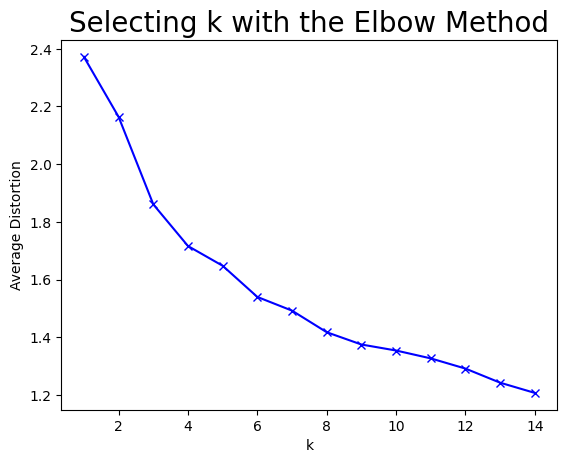

In [26]:
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
clusters = range(1, 15)
meanDistortions = []

for k in clusters:
    model = KMeans(n_clusters = k, random_state = 1, n_init = "auto")
    model.fit(data_pca)
    prediction = model.predict(k_means_df)
    distortion = (
        sum(np.min(cdist(k_means_df, model.cluster_centers_, "euclidean"), axis = 1))
        / k_means_df.shape[0]
    )

    meanDistortions.append(distortion)

    print("Number of Clusters:", k, "\tAverage Distortion:", distortion)

plt.plot(clusters, meanDistortions, "bx-")
plt.xlabel("k")
plt.ylabel("Average Distortion")
plt.title("Selecting k with the Elbow Method", fontsize = 20)
plt.show()

In [27]:
kmeans = KMeans(n_clusters = 4, random_state = 1, n_init = "auto")
kmeans.fit(k_means_df)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",1
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [29]:
# Creating a copy of the original data
df1 = df_transformed.copy()

# Adding K-Means cluster labels to the K-Means and original dataframes
k_means_df["KM_segments"] = kmeans.labels_
df1["KM_segments"] = kmeans.labels_

In [30]:
km_cluster_profile = df1.groupby("KM_segments").mean(numeric_only = True)

In [33]:
df1.head()

,sp500_log_return,breakeven_10y,real_yield_10y,slope_10y_2y,vix,vix3m,vix_term_spread,KM_segments
date,,,,,,,,
2011-10-06,0.018138,1.88,0.13,1.72,36.27,37.04,-0.77,1
2011-10-07,-0.008197,1.94,0.16,1.80,36.20,37.31,-1.11,1
2011-10-11,0.000544,1.95,0.23,1.86,32.86,34.06,-1.20,1
2011-10-12,0.009747,1.98,0.26,1.95,31.26,32.97,-1.71,3
2011-10-13,-0.002978,1.92,0.27,1.90,30.70,32.71,-2.01,3


In [34]:
# Creating the "count_in_each_segment" feature in K-Means cluster profile

km_cluster_profile["count_in_each_segment"] = (
    df1.groupby("KM_segments")["sp500_log_return"].count().values
)

In [35]:
km_cluster_profile.style.highlight_max(color = "lightgreen", axis = 0)

,sp500_log_return,breakeven_10y,real_yield_10y,slope_10y_2y,vix,vix3m,vix_term_spread,count_in_each_segment
KM_segments,,,,,,,,
0,0.001087,2.288987,1.752715,-0.011774,17.955305,19.892563,-1.937258,1116
1,-0.010035,1.666079,0.189075,0.639075,34.538150,33.130441,1.407709,227
2,0.000929,1.895354,0.380585,1.183600,14.165175,16.086917,-1.921742,1625
3,0.001803,2.254832,-0.626010,1.125661,20.834637,23.894974,-3.060337,772


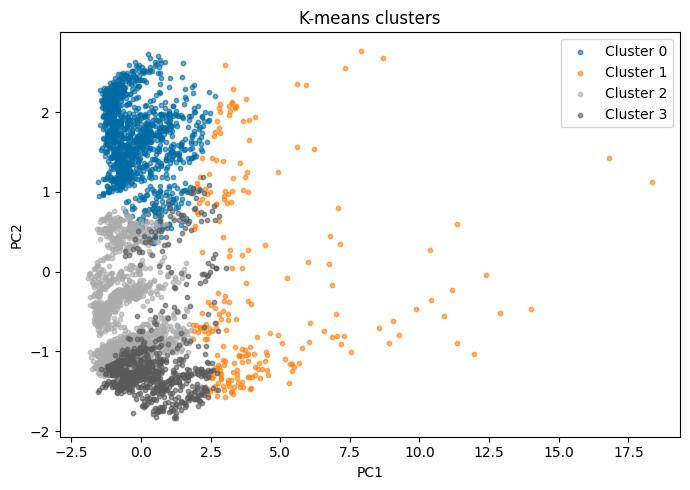

In [46]:
plt.style.use("tableau-colorblind10")
plt.figure(figsize=(7, 5))
for cluster in np.unique(kmeans.labels_):
    mask = kmeans.labels_ == cluster
    plt.scatter(data_pca.iloc[mask, 0], data_pca.iloc[mask, 1],
                s=10, alpha=0.6, label=f"Cluster {cluster}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-means clusters")
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    calinski_harabasz_score, davies_bouldin_score,
)

performance = []
for k in range(2, 11):
    candidate = KMeans(n_clusters=k, random_state=1, n_init="auto").fit(data_pca)
    labels = candidate.labels_
    performance.append([
        k, candidate.inertia_, silhouette_score(data_pca, labels),
        calinski_harabasz_score(data_pca, labels),
        davies_bouldin_score(data_pca, labels),
    ])

performance_df = pd.DataFrame(performance, columns=[
    "k", "Inertia", "Silhouette", "Calinski_Harabasz", "Davies_Bouldin",
]).set_index("k")
performance_df.round(3)

,Inertia,Silhouette,Calinski_Harabasz,Davies_Bouldin
k,,,,
2,21074.592,0.328,905.549,1.694
3,16650.650,0.269,1069.372,1.368
4,14367.078,0.279,1023.940,1.338
5,12785.196,0.277,978.286,1.316
6,11776.469,0.280,913.398,1.310
7,11080.500,0.282,847.832,1.276
8,9679.338,0.292,908.865,1.230
9,9384.247,0.256,834.709,1.349
10,8751.831,0.260,825.314,1.316


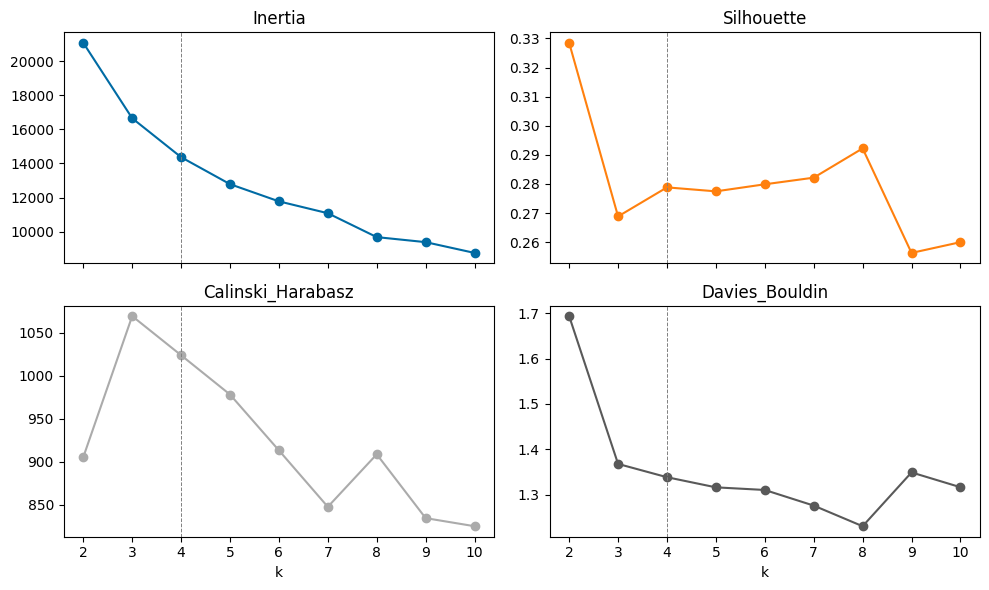

In [50]:
axes = performance_df.plot(subplots=True, layout=(2, 2), figsize=(10, 6),
                           sharex=True, legend=False, marker="o")
for ax, metric in zip(axes.flat, performance_df.columns):
    ax.set_title(metric)
    ax.axvline(kmeans.n_clusters, color="grey", linestyle="--", linewidth=0.7)
plt.tight_layout()
plt.show()

In [53]:
from scipy.cluster.hierarchy import linkage, cophenet, dendrogram
from scipy.spatial.distance import pdist

pairwise_distances = pdist(data_pca, metric="euclidean")
ward_linkage = linkage(pairwise_distances, method="ward")
cophenetic_correlation, _ = cophenet(ward_linkage, pairwise_distances)
cophenetic_correlation

np.float64(0.5033166867938752)